apt-get install -y unrar : install unrar utility
-y: automatically says yes to prompts
unrar x : commad to extract file
x : preservs directory structure in archive

In [ ]:
# Install unrar in Colab
!apt-get install -y unrar

# Path to your RAR file
rar_path = "/content/numerals.rar"

# Extraction directory
extract_dir = "/content/numerals"

# Create directory if it doesn't exist
import os
os.makedirs(extract_dir, exist_ok=True)

# Extract RAR file
!unrar x "{rar_path}" "{extract_dir}/"

print("Files extracted to:", extract_dir)

Streaming output truncated to the last 5000 lines.
Extracting  /content/numerals/numerals/n_7/78275.png                      79%  OK 
Extracting  /content/numerals/numerals/n_7/78276.png                      79%  OK 
Extracting  /content/numerals/numerals/n_7/78277.png                      79%  OK 
Extracting  /content/numerals/numerals/n_7/78278.png                      79%  OK 
Extracting  /content/numerals/numerals/n_7/78279.png                      79%  OK 
Extracting  /content/numerals/numerals/n_7/78280.png                      79%  OK 
Extracting  /content/numerals/numerals/n_7/78281.png                      79%  OK 
Extracting  /content/numerals/numerals/n_7/78282.png                      79%  OK 
Extracting  /content/numerals/numerals/n_7/78283.png                      79%  OK 
Extracting  /content/numerals/numerals/n_7/78284.png                      79%  OK 
Extracting  /content/numerals

Reads numeral images from folders named by class (0, 1, ..., 9).

Converts each image to grayscale and resizes to 32×32.

Flattens and stores pixel values in a DataFrame.

Labels each image numerically.

Prepares a dataset suitable for training models (e.g., classification).

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

data_path = '/content/numerals/numerals'

character_folders = sorted(os.listdir(data_path))

label_mapping = {folder: idx for idx, folder in enumerate(character_folders)}
print("Label mapping:", label_mapping)

image_data = []
image_labels = []

for label_name, label_idx in label_mapping.items():
    folder_path = os.path.join(data_path, label_name)
    image_files = sorted(os.listdir(folder_path))[:200]

    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (32, 32))
        image_data.append(img.flatten())
        image_labels.append(label_idx)

image_data = np.array(image_data)
image_labels = np.array(image_labels)

df = pd.DataFrame(image_data)
df['label'] = image_labels

print("DataFrame shape:", df.shape)
print(df.head())

Label mapping: {'n_0': 0, 'n_1': 1, 'n_2': 2, 'n_3': 3, 'n_4': 4, 'n_5': 5, 'n_6': 6, 'n_7': 7, 'n_8': 8, 'n_9': 9}
DataFrame shape: (2000, 1025)
     0    1    2    3    4    5    6    7    8    9  ...  1015  1016  1017  \
0  253  250  250  253  255  253  249  251  246  243  ...   249   254   255   
1  253  254  253  246  247  255  253  247  251  254  ...   248   241   252   
2  254  248  252  251  251  251  245  253  253  254  ...   252   255   255   
3  255  234  247  255  248  244  254  255  255  255  ...   246   254   255   
4  255  250  250  253  254  253  252  255  255  251  ...   251   255   255   

   1018  1019  1020  1021  1022  1023  label  
0   252   253   254   254   254   254      0  
1   255   255   255   255   255   255      0  
2   255   255   255   255   255   255      0  
3   252   253   255   255   255   255      0  
4   248   249   253   254   254   254      0  

[5 rows x 1025 columns]


set up the grid
group by lable
select and reshape img
plot img

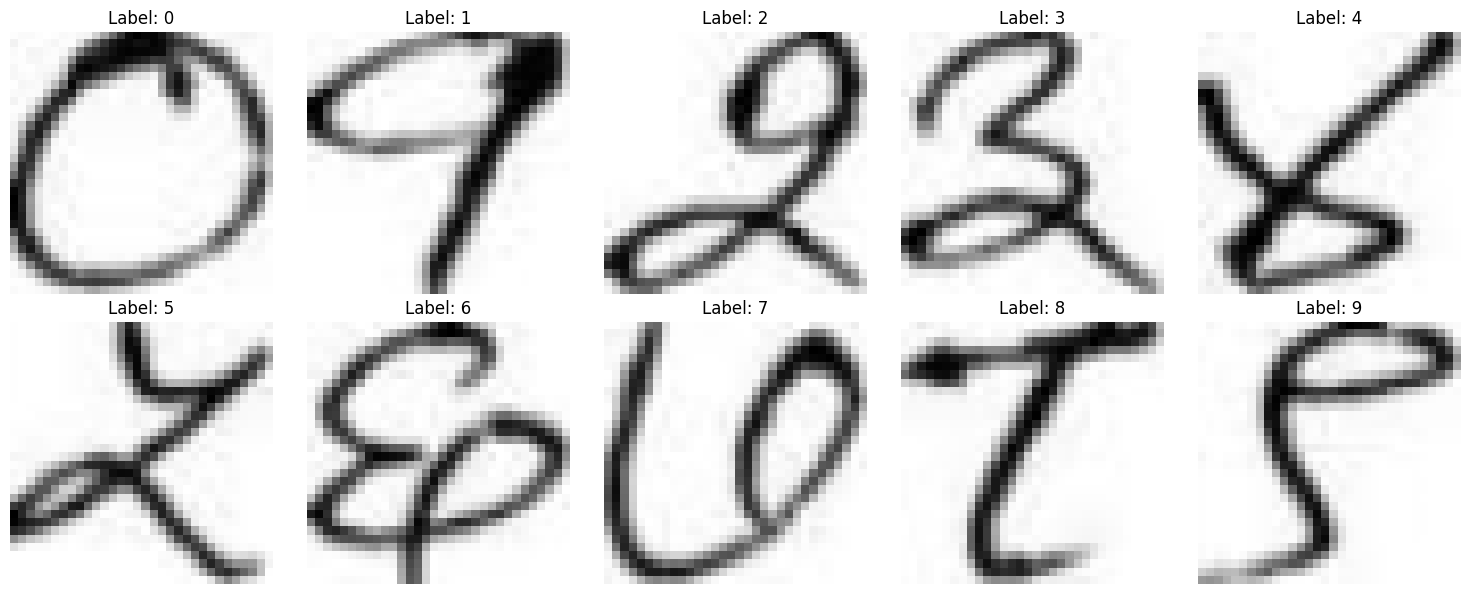

In [ ]:
rows = 2
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
axes = axes.flatten()

for idx, (label, group) in enumerate(df.groupby('label')):
    img_data = group.iloc[0, :-1]
    img = img_data.values.reshape(32, 32)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'Label: {label}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

Normalize the pixel values, Converts lables to numpy array, Reshape for cnn input, Split into train test set

In [ ]:
X = np.array(image_data).astype('float32') / 255.0
y = np.array(image_labels)

X = X.reshape(-1, 32, 32, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

FILL IN THE BLANKS

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3272 - loss: 2.0430 - val_accuracy: 0.7525 - val_loss: 1.0069
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7683 - loss: 0.8773 - val_accuracy: 0.7675 - val_loss: 0.8056
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8162 - loss: 0.6388 - val_accuracy: 0.8675 - val_loss: 0.5090
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8884 - loss: 0.4395 - val_accuracy: 0.8875 - val_loss: 0.4378
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8810 - loss: 0.4049 - val_accuracy: 0.8700 - val_loss: 0.4302
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9245 - loss: 0.3024 - val_accuracy: 0.8475 - val_loss: 0.4333
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9078 - loss: 0.3208 - val_accuracy: 0.8975 - val_loss: 0.3805
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9142 - loss: 0.2655 - val_accuracy: 0.9050 - val_loss

runs the trained model on unseen test data and returns the loss and accuracy.


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8821 - loss: 0.3104 
Test accuracy: 0.8700


This code uses model.predict() to get probability predictions for each class, then displays the first test image with matplotlib.
np.argmax(predictions[0]) picks the class with the highest predicted probability, and it’s shown alongside the true label in the plot title.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


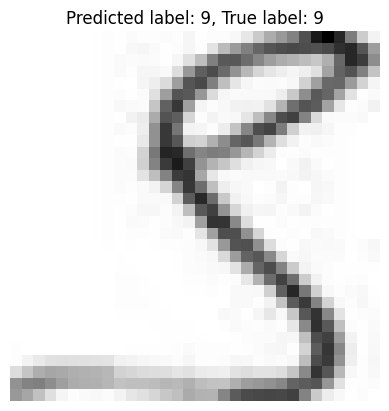

In [ ]:
predictions = model.predict(X_test)

import matplotlib.pyplot as plt

plt.imshow(X_test[0].reshape(32, 32), cmap='gray')
plt.title(f'Predicted label: {np.argmax(predictions[0])}, True label: {y_test[0]}')
plt.axis('off')
plt.show()

This code plots the training vs. validation accuracy and loss over epochs using data from history.history.
It creates two side-by-side graphs to visualize how the model’s performance and error changed during training.

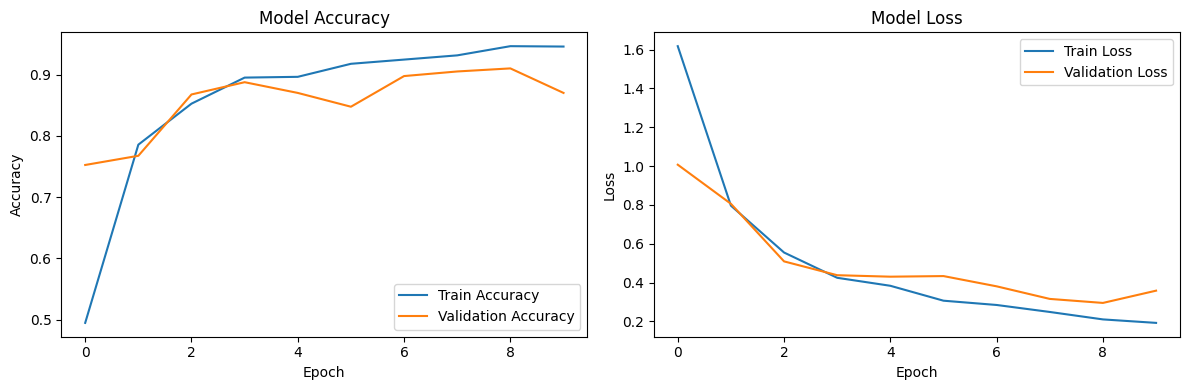

In [ ]:
plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Evaluates model prediction in deatail : np.argmax(predictions, axis=1) converts predicted probabilities into class labels.

confusion_matrix() builds a table showing how often each true label was predicted as each class.

A Seaborn heatmap visualizes this matrix, making misclassifications easy to spot.

classification_report() prints precision, recall, and F1-score for each class, giving deeper insight into performance.

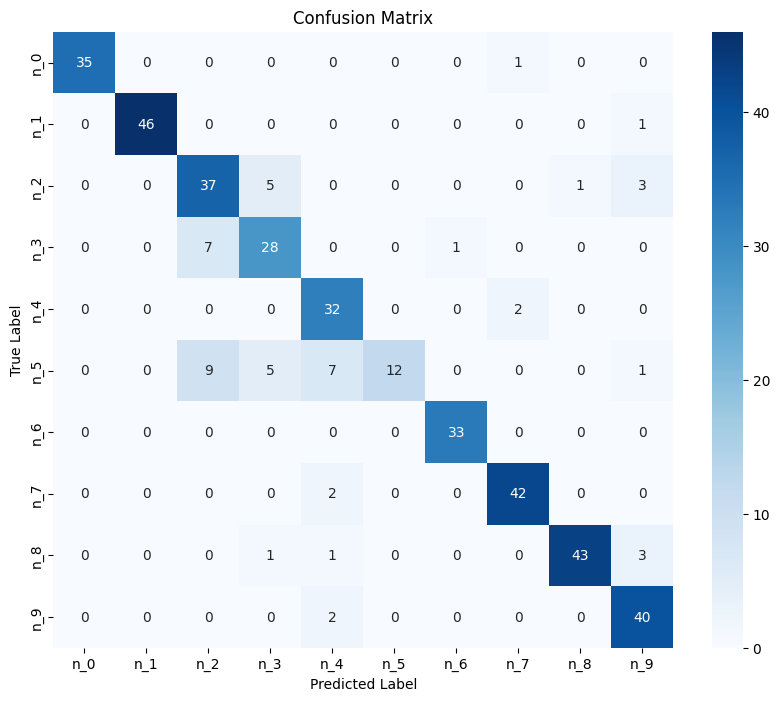

Classification Report:
              precision    recall  f1-score   support

         n_0       1.00      0.97      0.99        36
         n_1       1.00      0.98      0.99        47
         n_2       0.70      0.80      0.75        46
         n_3       0.72      0.78      0.75        36
         n_4       0.73      0.94      0.82        34
         n_5       1.00      0.35      0.52        34
         n_6       0.97      1.00      0.99        33
         n_7       0.93      0.95      0.94        44
         n_8       0.98      0.90      0.93        48
         n_9       0.83      0.95      0.89        42

    accuracy                           0.87       400
   macro avg       0.89      0.86      0.86       400
weighted avg       0.89      0.87      0.86       400



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

report = classification_report(y_test, y_pred, target_names=label_mapping.keys())
print("Classification Report:")
print(report)

In [ ]:

model.save('my_model.keras')
# model.save('my_model.h5')
